In [2]:
import os
import json
import zlib
import base64
import numpy as np
from PIL import Image
from io import BytesIO
from torch.utils.data import Dataset
import torchvision.transforms as T


class CIHPDataset(Dataset):
    def __init__(self, root_dir, target_classes=None, transform=None, target_size=(512, 512)):
        self.img_dir = os.path.join(root_dir, 'img')
        self.ann_dir = os.path.join(root_dir, 'ann')
        self.filenames = sorted(f for f in os.listdir(self.img_dir) if f.endswith('.jpg'))
        self.target_classes = target_classes or ['face', 'head']
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]
        image_path = os.path.join(self.img_dir, filename)
        ann_path = os.path.join(self.ann_dir, filename + '.json')

        image = Image.open(image_path).convert('RGB')
        mask = self._load_mask_from_json(ann_path, image.size)

        # Resize
        image = image.resize(self.target_size, Image.BILINEAR)
        mask = mask.resize(self.target_size, Image.NEAREST)

        # To tensor
        image = T.ToTensor()(image)
        mask = np.array(mask, dtype=np.int64)

        return image, mask

    def _load_mask_from_json(self, ann_path, image_size):
        width, height = image_size
        mask = Image.new('L', (width, height), 0)

        with open(ann_path, 'r') as f:
            data = json.load(f)

        for obj in data.get('objects', []):
            class_title = obj.get('classTitle', '').lower()
            if class_title not in self.target_classes:
                continue

            if obj.get('geometryType') != 'bitmap':
                continue

            bitmap = obj['bitmap']
            origin_x, origin_y = bitmap['origin']
            b64_data = bitmap['data']
            raw = zlib.decompress(base64.b64decode(b64_data))
            submask = Image.open(BytesIO(raw)).convert('L')

            # Paste submask into full image mask
            mask.paste(1, box=(origin_x, origin_y), mask=submask)

        return mask


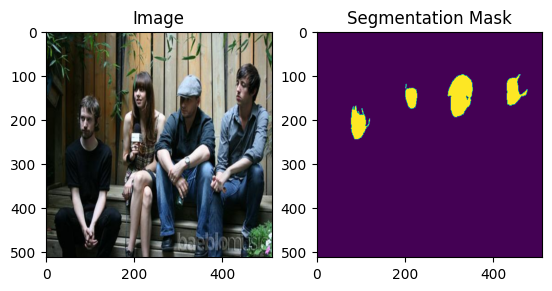

In [4]:
dataset = CIHPDataset('training', target_classes=['face', 'hat', 'head'])
image, mask = dataset[1]

# Show it
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1); plt.imshow(image.permute(1, 2, 0)); plt.title("Image")
plt.subplot(1, 2, 2); plt.imshow(mask); plt.title("Segmentation Mask")
plt.show()


In [ ]:
# cihp_training_pipeline.py
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
import torchvision.transforms as T
from tqdm import tqdm

# --- Config ---
ROOT_DIR = 'C:/Users/alexi/OneDrive/Desktop/my_code_projects/headcounter data/training'  # 'validation' or 'testing' for val/test
TARGET_CLASSES = ['face', 'hat']  # define classes you care about
NUM_CLASSES = len(TARGET_CLASSES) + 1  # +1 for background
BATCH_SIZE = 4
NUM_EPOCHS = 20
IMG_SIZE = (512, 512)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from torch.utils.data import Subset
import random


# --- Dataset ---
train_dataset = CIHPDataset(
    root_dir=ROOT_DIR,
    target_classes=TARGET_CLASSES,
    target_size=IMG_SIZE
)
subset_size = 500
indices = random.sample(range(len(train_dataset)), subset_size)
train_subset = Subset(train_dataset, indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# --- Model ---
model = models.segmentation.deeplabv3_mobilenet_v3_large(pretrained=False)
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model = model.to(DEVICE)

# --- Loss + Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# --- Training Loop ---
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)['out']  # shape: [B, C, H, W]
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# --- Save Model ---
torch.save(model.state_dict(), 'deeplabv3_cihp.pth')
print("Training complete. Model saved.")


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'training\\img'

In [4]:
# cihp_training_pipeline.py
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import models
import torchvision.transforms as T
from tqdm import tqdm
import random

# --- Config ---
ROOT_DIR = 'C:/Users/alexi/OneDrive/Desktop/my_code_projects/headcounter data/training'
TARGET_CLASSES = ['face', 'hat']
NUM_CLASSES = len(TARGET_CLASSES) + 1
BATCH_SIZE = 4
NUM_EPOCHS = 50
IMG_SIZE = (512, 512)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Dataset ---
train_dataset = CIHPDataset(
    root_dir=ROOT_DIR,
    target_classes=TARGET_CLASSES,
    target_size=IMG_SIZE
)

# --- Model ---
model = models.segmentation.deeplabv3_mobilenet_v3_large(pretrained=False)
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model = model.to(DEVICE)

# --- Loss + Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# --- Training Loop ---
for epoch in range(NUM_EPOCHS):
    # Create a new random subset of 125 unique samples each epoch
    subset_size = 500
    indices = random.sample(range(len(train_dataset)), subset_size)
    sampler = SubsetRandomSampler(indices)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)

    model.train()
    running_loss = 0.0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)['out']
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# --- Save Model ---
torch.save(model.state_dict(), 'deeplabv3_cihp_2.pth')
print("Training complete. Model saved.")


C:\Users\alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Epoch 1/50: 100%|██████████| 125/125 [00:33<00:00,  3.70it/s]


Epoch 1, Loss: 0.5169


Epoch 2/50: 100%|██████████| 125/125 [00:31<00:00,  3.95it/s]


Epoch 2, Loss: 0.1974


Epoch 3/50: 100%|██████████| 125/125 [00:34<00:00,  3.67it/s]


...

Epoch 48, Loss: 0.0417


Epoch 49/50: 100%|██████████| 125/125 [00:25<00:00,  4.87it/s]


Epoch 49, Loss: 0.0380


Epoch 50/50: 100%|██████████| 125/125 [00:25<00:00,  4.88it/s]

Epoch 50, Loss: 0.0344
Training complete. Model saved.


C:\Users\alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\alexi\AppData\Local\Temp\ipykernel_11844\2616606647.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary 

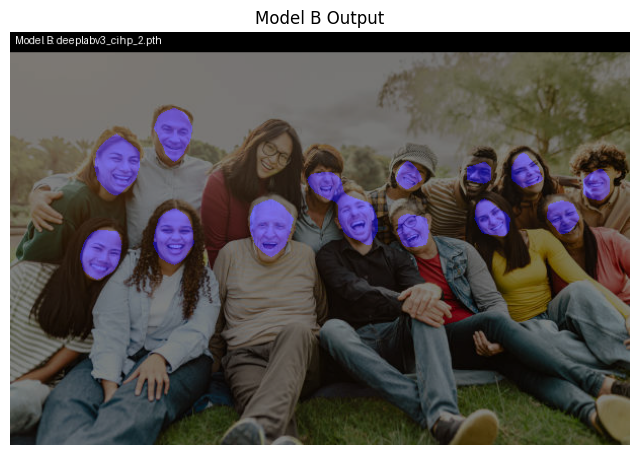

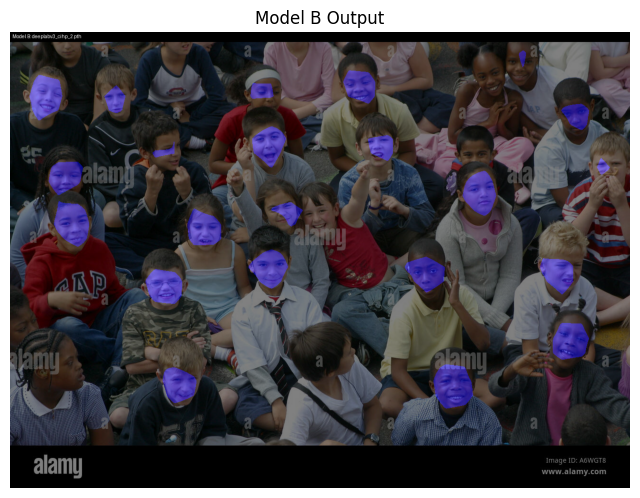

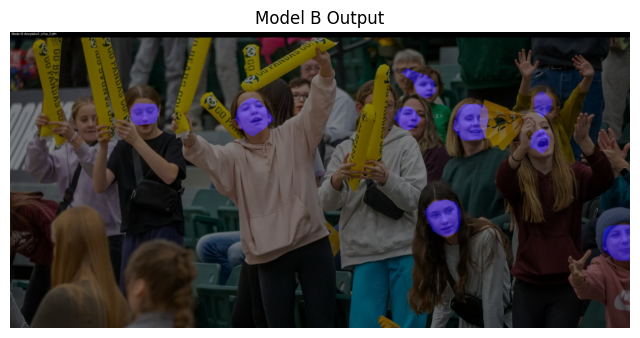

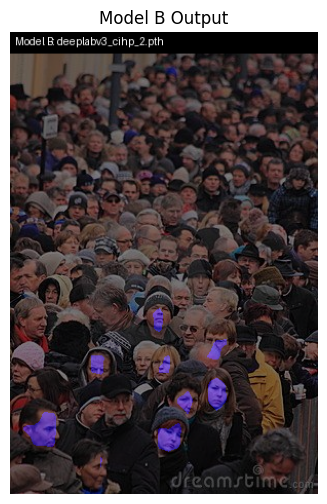

In [11]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import models
from PIL import Image, ImageDraw, ImageFont
import torchvision.transforms as T
import matplotlib.pyplot as plt

# --- Config ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_CLASSES = 3
IMG_SIZE = (512, 512)
FACE_CLASS = 1
ALPHA = 0.5

# --- Load Model B ---
def load_model(path):
    model = models.segmentation.deeplabv3_mobilenet_v3_large(pretrained=False)
    model.classifier[4] = torch.nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

model_B = load_model('deeplabv3_cihp_2.pth')

# --- Preprocess ---
def preprocess_image(img_path):
    image = Image.open(img_path).convert('RGB')
    original_size = image.size
    image_resized = image.resize(IMG_SIZE, Image.BILINEAR)
    tensor = T.ToTensor()(image_resized).unsqueeze(0).to(DEVICE)
    return tensor, original_size, np.array(image)

# --- Predict ---
def predict_mask(model, tensor, original_size):
    with torch.no_grad():
        out = model(tensor)['out']
        logits = F.interpolate(out, size=original_size[::-1], mode='bilinear', align_corners=False)
        predicted = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    return predicted

# --- Overlay mask with 50% alpha ---
def overlay_mask(image_np, mask, face_class=FACE_CLASS, color=(0, 0, 255)):
    mask_bool = (mask == face_class)
    mask_rgb = np.zeros_like(image_np)
    mask_rgb[mask_bool] = color
    overlay = cv2.addWeighted(image_np, 1 - ALPHA, mask_rgb, ALPHA, 0)
    return overlay

# --- Draw caption ---
def draw_caption(img_np, text):
    img = Image.fromarray(img_np)
    draw = ImageDraw.Draw(img)
    font = ImageFont.load_default()
    draw.rectangle([0, 0, img.size[0], 20], fill=(0, 0, 0, 128))
    draw.text((5, 3), text, fill=(255, 255, 255), font=font)
    return np.array(img)

# --- Show result ---
def show_model_B_output(img_path):
    tensor, original_size, orig_image = preprocess_image(img_path)
    mask_B = predict_mask(model_B, tensor, original_size)
    overlay_B = overlay_mask(orig_image, mask_B)
    overlay_B = draw_caption(overlay_B, "Model B: deeplabv3_cihp_2.pth")

    plt.figure(figsize=(8, 6))
    plt.imshow(overlay_B)
    plt.axis('off')
    plt.title("Model B Output")
    plt.show()

# --- Run on image paths ---
image_paths = [
    'istockphoto-1480574526-612x612.jpg',
    'crowd-of-primary-school-children-in-the-school-playground-A6WGT8.jpg',
    'convert.webp',
    'cd097ca3e6a09fa9d231f10b549d14b9.jpg'
]

for path in image_paths:
    show_model_B_output(path)


C:\Users\alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\alexi\AppData\Local\Temp\ipykernel_11844\426619007.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary c

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


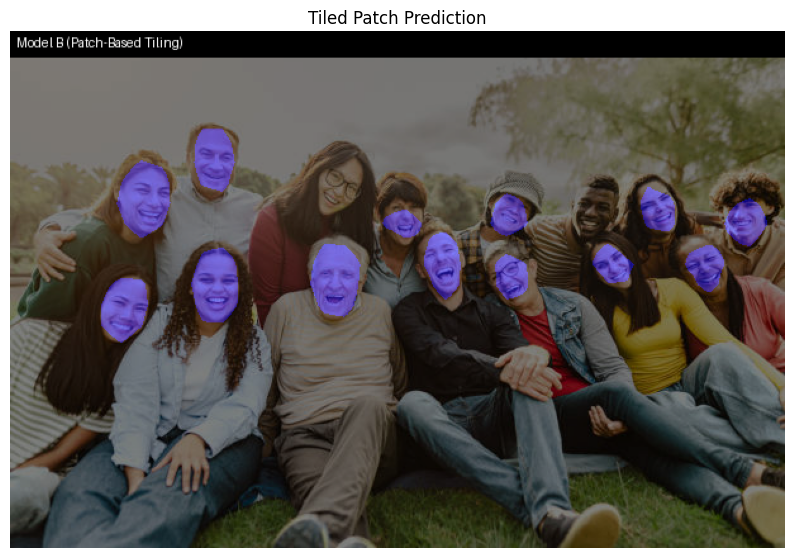

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


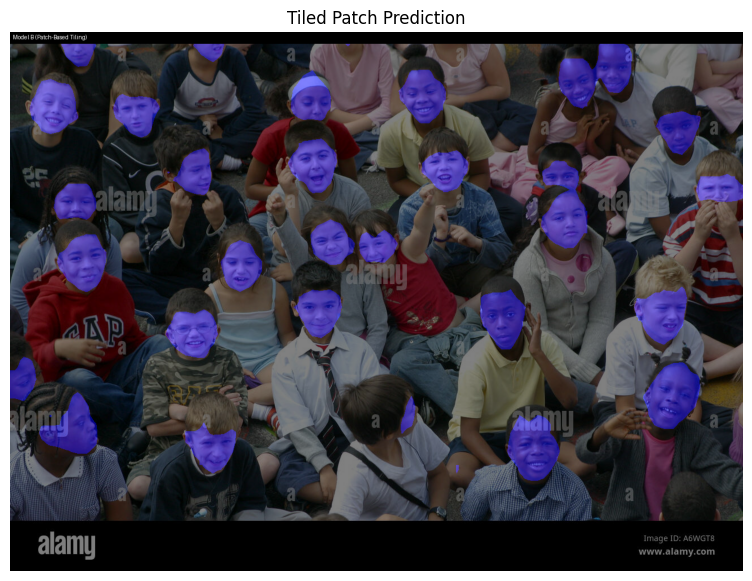

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


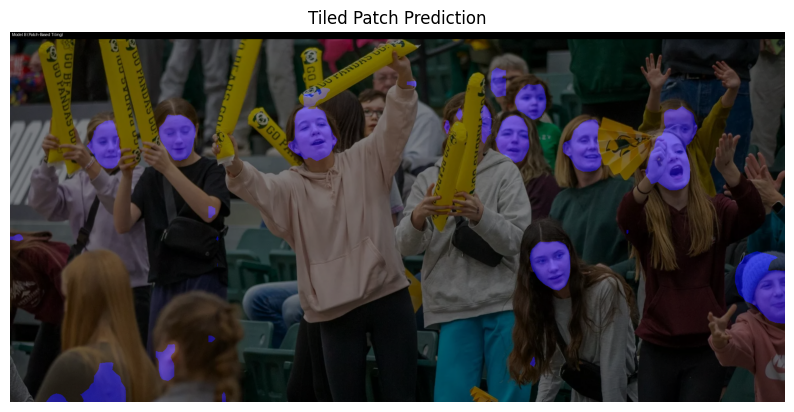

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


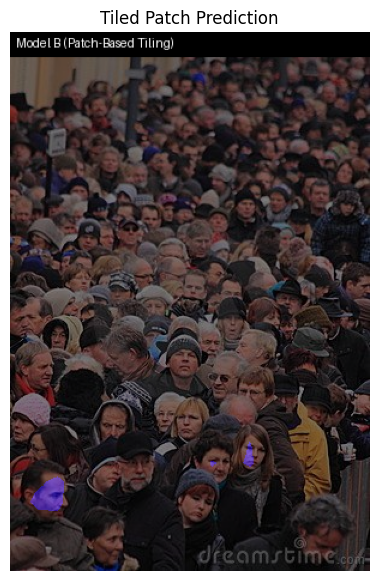

In [17]:
def patchwise_predict(model, image_np, tile_size=512, stride=256, face_class=1):
    h, w, _ = image_np.shape
    full_mask = np.zeros((h, w), dtype=np.uint8)

    transform = T.Compose([
        T.Resize((tile_size, tile_size)),
        T.ToTensor()
    ])

    for y in range(0, h, stride):
        for x in range(0, w, stride):
            # Extract tile
            x_end = min(x + tile_size, w)
            y_end = min(y + tile_size, h)
            tile = image_np[y:y_end, x:x_end]
            
            # Pad if necessary
            pad_right = tile_size - (x_end - x)
            pad_bottom = tile_size - (y_end - y)
            tile_padded = cv2.copyMakeBorder(tile, 0, pad_bottom, 0, pad_right, cv2.BORDER_REFLECT)

            # Predict
            image_tensor = transform(Image.fromarray(tile_padded)).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                out = model(image_tensor)['out']
                logits = F.interpolate(out, size=(tile_size, tile_size), mode='bilinear', align_corners=False)
                pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

            # Crop padding and place prediction
            pred_mask = pred_mask[:y_end - y, :x_end - x]
            full_mask[y:y_end, x:x_end] = np.maximum(full_mask[y:y_end, x:x_end], (pred_mask == face_class).astype(np.uint8))

    return full_mask

def preprocess_image(img_path):
    image = Image.open(img_path).convert('RGB')
    original_size = image.size
    image_resized = image.resize(IMG_SIZE, Image.BILINEAR)
    tensor = T.ToTensor()(image_resized).unsqueeze(0).to(DEVICE)
    return tensor, original_size, np.array(image)

def show_tiled_prediction(image_path):
    image = Image.open(image_path).convert('RGB')
    image_np = np.array(image)
    mask = patchwise_predict(model_B, image_np, tile_size=512, stride=256, face_class=1)

    # Overlay
    overlay = overlay_mask(image_np, mask, face_class=1, color=(0, 0, 255))
    overlay = draw_caption(overlay, "Model B (Patch-Based Tiling)")

    plt.figure(figsize=(10, 7))
    plt.imshow(overlay)
    plt.axis('off')
    plt.title("Tiled Patch Prediction")
    plt.show()

def load_model(path):
    model = models.segmentation.deeplabv3_mobilenet_v3_large(pretrained=False)
    model.classifier[4] = torch.nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

model_B = load_model('deeplabv3_cihp_2.pth')

image_paths = [
    'istockphoto-1480574526-612x612.jpg',
    'crowd-of-primary-school-children-in-the-school-playground-A6WGT8.jpg',
    'convert.webp',
    'cd097ca3e6a09fa9d231f10b549d14b9.jpg'
]

for path in image_paths:
    image = preprocess_image(path)[2]
    result = patchwise_predict(model=model_B, image_np=image)
    print(result)
    show_tiled_prediction(path)




In [5]:
from torchvision import models
import torch
import torch.nn as nn

NUM_CLASSES = 3  # background + face + hat (match training)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = models.segmentation.deeplabv3_mobilenet_v3_large(pretrained=False)
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model.load_state_dict(torch.load('deeplabv3_cihp_2.pth', map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

from PIL import Image
import torchvision.transforms as T

def preprocess_image(img_path, img_size=(512, 512)):
    image = Image.open(img_path).convert('RGB')
    original_size = image.size
    image = image.resize(img_size, Image.BILINEAR)
    tensor = T.ToTensor()(image).unsqueeze(0).to(DEVICE)
    return tensor, original_size

import torch.nn.functional as F

def predict_mask(model, input_tensor, original_size):
    with torch.no_grad():
        output = model(input_tensor)['out']
        logits = F.interpolate(output, size=original_size[::-1], mode='bilinear', align_corners=False)
        predicted = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    return predicted  # shape: (H, W), values: 0 (bg), 1 (face), 2 (hat)

import cv2
import numpy as np

def count_faces(mask, face_class=1):
    face_mask = (mask == face_class).astype(np.uint8)
    num_labels, labels_im = cv2.connectedComponents(face_mask)
    return num_labels - 1  # subtract background


image_path = 'istockphoto-1480574526-612x612.jpg'  # replace with your image path
tensor, original_size = preprocess_image(image_path)
mask = predict_mask(model, tensor, original_size)
num_faces = count_faces(mask)

print(f"Detected {num_faces} face(s).")

image_path = 'cd097ca3e6a09fa9d231f10b549d14b9.jpg'  # replace with your image path
tensor, original_size = preprocess_image(image_path)
mask = predict_mask(model, tensor, original_size)
num_faces = count_faces(mask)

print(f"Detected {num_faces} face(s).")

image_path = 'crowd-of-primary-school-children-in-the-school-playground-A6WGT8.jpg'  # replace with your image path
tensor, original_size = preprocess_image(image_path)
mask = predict_mask(model, tensor, original_size)
num_faces = count_faces(mask)

print(f"Detected {num_faces} face(s).")

image_path = 'convert.webp'  # replace with your image path
tensor, original_size = preprocess_image(image_path)
mask = predict_mask(model, tensor, original_size)
num_faces = count_faces(mask)

print(f"Detected {num_faces} face(s).")





C:\Users\alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\alexi\AppData\Local\Temp\ipykernel_11844\1585010985.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary 

Detected 13 face(s).
Detected 9 face(s).
Detected 22 face(s).
Detected 9 face(s).


C:\Users\alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\alexi\AppData\Local\Temp\ipykernel_11844\3557577388.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary 

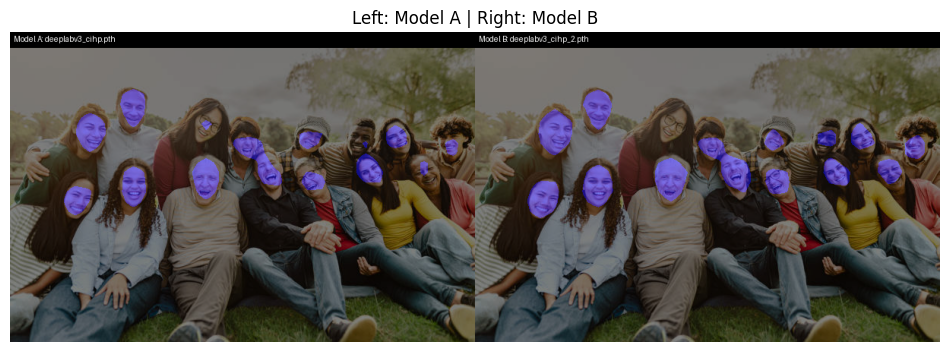

Saved: comparison_1.jpg


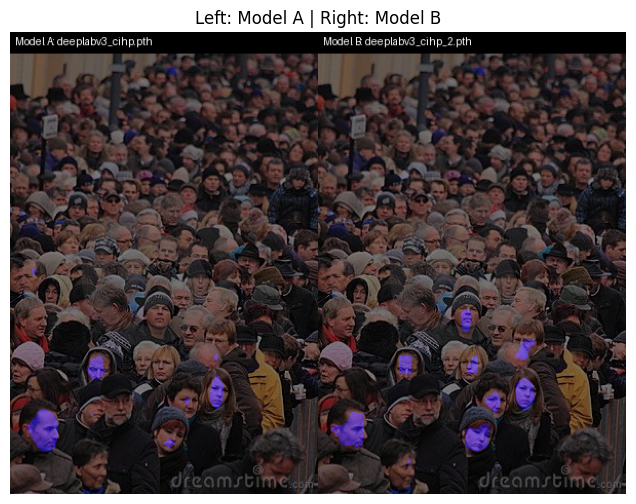

Saved: comparison_2.jpg


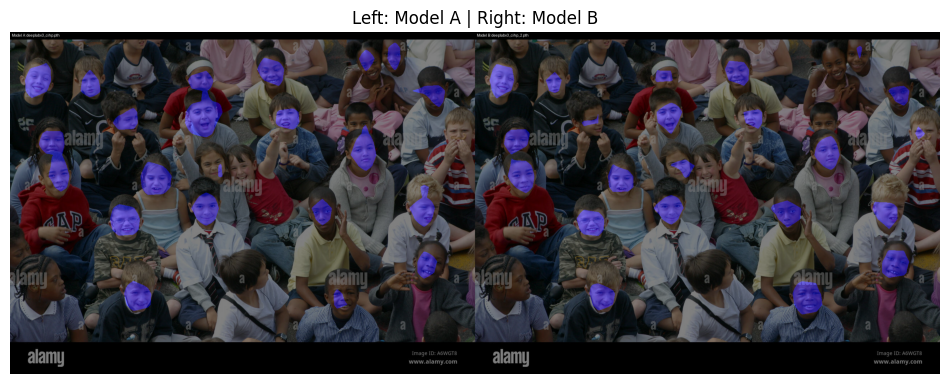

Saved: comparison_3.jpg


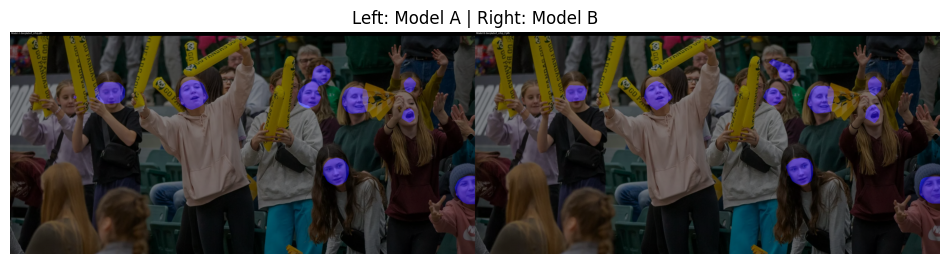

Saved: comparison_4.jpg


In [9]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import models
from PIL import Image, ImageDraw, ImageFont
import torchvision.transforms as T
import matplotlib.pyplot as plt

# --- Config ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_CLASSES = 3
IMG_SIZE = (512, 512)
FACE_CLASS = 1
ALPHA = 0.5

# --- Load both models ---
def load_model(path):
    model = models.segmentation.deeplabv3_mobilenet_v3_large(pretrained=False)
    model.classifier[4] = torch.nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

model_A = load_model('deeplabv3_cihp.pth')
model_B = load_model('deeplabv3_cihp_2.pth')

# --- Preprocess ---
def preprocess_image(img_path):
    image = Image.open(img_path).convert('RGB')
    original_size = image.size
    image_resized = image.resize(IMG_SIZE, Image.BILINEAR)
    tensor = T.ToTensor()(image_resized).unsqueeze(0).to(DEVICE)
    return tensor, original_size, np.array(image)

# --- Predict ---
def predict_mask(model, tensor, original_size):
    with torch.no_grad():
        out = model(tensor)['out']
        logits = F.interpolate(out, size=original_size[::-1], mode='bilinear', align_corners=False)
        predicted = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    return predicted

# --- Overlay mask with 50% alpha ---
def overlay_mask(image_np, mask, face_class=FACE_CLASS, color=(0, 0, 255)):
    mask_bool = (mask == face_class)
    mask_rgb = np.zeros_like(image_np)
    mask_rgb[mask_bool] = color
    overlay = cv2.addWeighted(image_np, 1 - ALPHA, mask_rgb, ALPHA, 0)
    return overlay

# --- Draw caption ---
def draw_caption(img_np, text):
    img = Image.fromarray(img_np)
    draw = ImageDraw.Draw(img)
    font = ImageFont.load_default()
    draw.rectangle([0, 0, img.size[0], 20], fill=(0, 0, 0, 128))
    draw.text((5, 3), text, fill=(255, 255, 255), font=font)
    return np.array(img)

# --- Compare models and save side-by-side images ---
def compare_models_on_image(img_path, save_path=None):
    tensor, original_size, orig_image = preprocess_image(img_path)

    mask_A = predict_mask(model_A, tensor, original_size)
    mask_B = predict_mask(model_B, tensor, original_size)

    overlay_A = overlay_mask(orig_image, mask_A)
    overlay_B = overlay_mask(orig_image, mask_B)

    overlay_A = draw_caption(overlay_A, "Model A: deeplabv3_cihp.pth")
    overlay_B = draw_caption(overlay_B, "Model B: deeplabv3_cihp_2.pth")

    # Combine side by side
    combined = np.hstack((overlay_A, overlay_B))
    
    if save_path:
        cv2.imwrite(save_path, cv2.cvtColor(combined, cv2.COLOR_RGB2BGR))
    
    return combined

def show_comparison(img_np):
    plt.figure(figsize=(12, 6))
    plt.imshow(img_np)
    plt.axis('off')
    plt.title("Left: Model A | Right: Model B")
    plt.show()


# --- Run on example images ---
image_paths = [
    'istockphoto-1480574526-612x612.jpg',
    'cd097ca3e6a09fa9d231f10b549d14b9.jpg',
    'crowd-of-primary-school-children-in-the-school-playground-A6WGT8.jpg',
    'convert.webp'
]

for i, path in enumerate(image_paths):

    result = compare_models_on_image(path, save_path=f'comparison_{i+1}.jpg')
    show_comparison(result)
    print(f"Saved: comparison_{i+1}.jpg")

import matplotlib.pyplot as plt

def show_comparison(img_np):
    plt.figure(figsize=(12, 6))
    plt.imshow(img_np)
    plt.axis('off')
    plt.title("Left: Model A | Right: Model B")
    plt.show()



In [13]:
image, _ = dataset[1]  # Already resized & tensorized
input_tensor = image.unsqueeze(0).to(DEVICE)  # Add batch dim
original_size = (image.shape[2], image.shape[1])  # (W, H) from tensor shape

mask = predict_mask(model, input_tensor, original_size)
num_faces = count_faces(mask)

print(f"Detected {num_faces} face(s).")


Detected 4 face(s).
